In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx

# Boids

In [ ]:
def get_adjacency(p):
    A = np.zeros((N, N))
    for j in range(N):
        for i in range(j):
            r = np.linalg.norm(p[i] - p[j])
            if r <= R:
                A[i, j] = 1
    A += A.T
    return A

def get_u_sep(p, v, A):
    u_sep = np.zeros((N, 2))
    for i in range(N):
        tmp = np.zeros((N, 2))
        for j in range(N):
            if i == j or A[i, j] == 0:
                continue
            r = p[i] - p[j]
            rmag = np.linalg.norm(r)
            if rmag > 1e-8:
                tmp[j] = max(0, r0 - rmag)*r/rmag
        u_sep[i] = k_sep*np.sum(tmp, axis=0)
    return u_sep

def get_u_ali(p, v, A, d):
    u_ali = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            vbar = np.sum(A[i, :, None] * v, axis=0) / d[i]
            u_ali[i] = k_ali * (vbar - v[i])
    return u_ali

def get_u_coh(p, v, A, d):
    u_coh = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            pbar = np.sum(A[i, :, None] * p, axis=0) / d[i]
            u_coh[i] = k_coh * (pbar - p[i])
    return u_coh

def f(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency(p)
    d = A @ np.ones(N)

    u_sep = get_u_sep(p, v, A)
    u_ali = get_u_ali(p, v, A, d)
    u_coh = get_u_coh(p, v, A, d)

    pdot = v
    vdot = u_sep + u_ali + u_coh

    return np.concatenate((pdot, vdot)).flatten()


def plot_boid_trajectories(sol, N):

    p_traj = sol.y[:2*N, :]


    plt.figure(figsize=(6, 6))
    for i in range(N):
        plt.plot(p_traj[2*i], p_traj[2*i+1], lw=1.2, alpha=0.8)
    
    plt.title("Boid Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid()
    plt.show()

def plot_boid_trajectories(sol, N):

    p_traj = sol.y[:2*N, :]             # positions over time (flattened)
    T = len(sol.t)

    # Reshape into (N, 2, T)
    p_traj = p_traj.reshape(N, 2, T)

    # Plot trajectories
    plt.figure(figsize=(6, 6))
    for i in range(N):
        plt.plot(p_traj[i, 0, :], p_traj[i, 1, :], lw=1.2, alpha=0.8)
        plt.scatter(p_traj[i, 0, -1], p_traj[i, 1, -1], s=10)  # final position
    
    plt.title("Boid Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

def get_D_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) 
    L = D-A
    return D,L

def get_lambda_2(sol):
    lambda_2_ary = np.zeros(len(t_eval))
    components_ary = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        p = sol.y[:2*N, i].reshape(N, 2)
        A = get_adjacency(p)
        D,L = get_D_L(A)
        vals = np.real(np.linalg.eigvals(L))
        vals_sorted = np.sort(vals)
        G = nx.Graph(A)
        nc=nx.number_connected_components(G)
        components_ary[i] = nc
        lambda_2 = vals_sorted[nc]
        #print(lambda_2)
        lambda_2_ary[i]=lambda_2
    return lambda_2_ary, components_ary


In [87]:
N = 20
x20 = 0.7 * np.random.uniform(-1,1,(2*N,2))

In [88]:
N = 50
x50 = 0.7 * np.random.uniform(-1,1,(2*N,2))

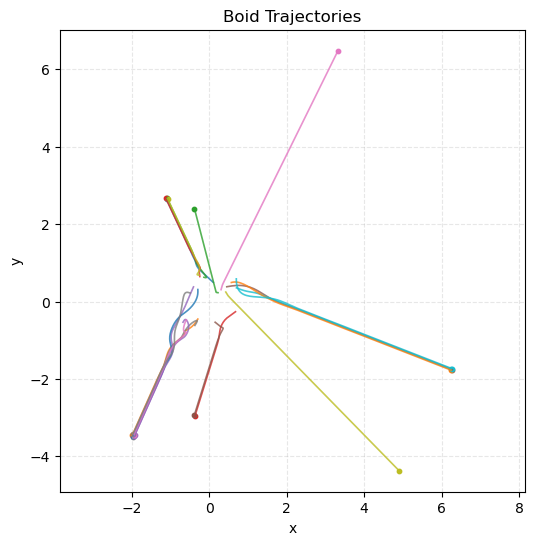

In [ ]:
N=20
R = 0.3
k_sep = 2
k_ali = 1
k_coh = 2
r0 = 0.05

# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
b20_sol = solve_ivp(f, tspan, x20.flatten(), t_eval=t_eval)

plot_boid_trajectories(b20_sol,N)

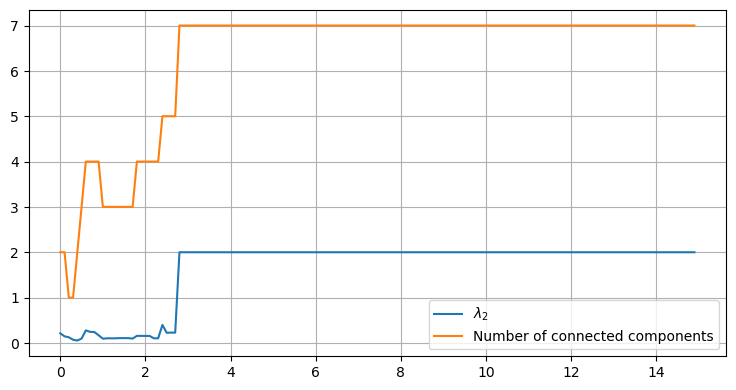

In [ ]:
l2,ca = get_lambda_2(b20_sol)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

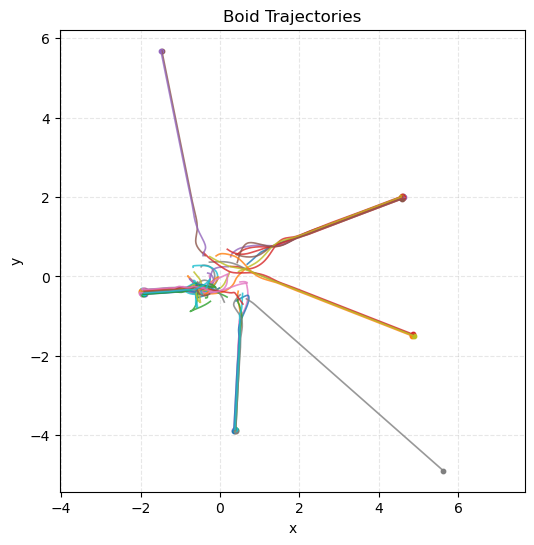

In [91]:
N=50
R = 0.3
k_sep = 2
k_ali = 1
k_coh = 2
r0 = 0.05

# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
b50_sol = solve_ivp(f, tspan, x50.flatten(), t_eval=t_eval)

plot_boid_trajectories(b50_sol,N)

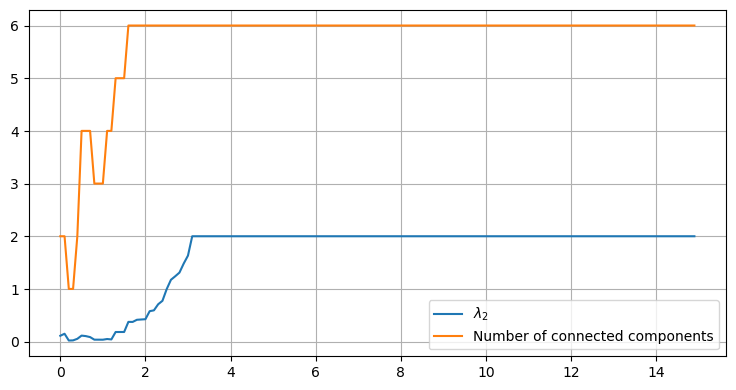

In [92]:
l2,ca = get_lambda_2(b50_sol)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

# Olfati–Saber

In [105]:
def signorm(z,epsilon = 0.1):
    return (np.sqrt(1+epsilon*np.linalg.norm(z)**2)-1)/epsilon

h = 0.5
def bump(s,h=0.5):
    if 0 <= s and s <= h:
        return 1
    elif h<= s and s<= 1:
        return 1/2*(1 + np.cos(np.pi * (s-h)/(1-h)))
    else:
        return 0
    
def get_adjacency_2(p):
    A = np.zeros((N, N))
    for j in range(N):
        for i in range(j):
            A[i,j] = bump(np.linalg.norm(p[i]-p[j])/R)
    A += A.T
    return A

def sigma1(z):
    return z/(np.sqrt(1+z*z))

def phi(z,a=0.1,b=0.5):
    c = abs(a-b)/np.sqrt(4*a*b)
    return 0.5*((a+b)*sigma1(z+c)+(a-b))

def phi_alpha(z):
    z1 = bump(z/R)
    z2 = phi(z-d)
    return z1*z2

def gradz(pi,pj):
    return (pi-pj)/(np.sqrt(1 + epsilon*np.linalg.norm(pi-pj)**2))

def get_u_int(p,v,A):
    u_int = np.zeros((N, 2))
    for i in range(N):
        u_int[i] = np.sum(np.array([A[i,j]*phi_alpha(signorm(p[i]-p[j]))*gradz(p[i],p[j]) for j in range(N)]))
    return u_int



def get_u_ali_2(p, v, A):
    u_ali = np.zeros((N, 2))
    for i in range(N):
        u_ali[i] = -np.sum(np.array([A[i,j]*(v[i]-v[j]) for j in range(N)]),axis=0)
    return u_ali
c1=1.
c2=1.
def get_u_gamma_static(p, v, A,c1,c2):
    u_gamma = np.zeros((N,2))
    for i in range(N):
        u_gamma[i]=-c1*p[i]-c2*v[i]
    return u_gamma

def get_u_gamma_dynamic(p, v, A,c1,c2,vgamma,t):
    u_gamma = np.zeros((N,2))
    for i in range(N):
        u_gamma[i]=-c1*(p[i]-vgamma*t)-c2*(v[i]-vgamma)
    return u_gamma


def f_static(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency_2(p)

    u_int = get_u_int(p, v, A)
    u_ali = get_u_ali_2(p, v, A)
    u_gamma = get_u_gamma_static(p,v,A,c1,c2)

    pdot = v
    vdot = u_int + u_ali + u_gamma

    return np.concatenate((pdot, vdot)).flatten()

def f_dynamic(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency_2(p)

    u_int = get_u_int(p, v, A)
    u_ali = get_u_ali_2(p, v, A)
    u_gamma = get_u_gamma_dynamic(p, v, A,c1,c2,vgamma,t)

    pdot = v
    vdot = u_int + u_ali + u_gamma

    return np.concatenate((pdot, vdot)).flatten()

def get_avg_velocity_error(sol):
    v_traj = sol.y[2*N:,:]  
    v_traj = v_traj.reshape(N, 2, len(t_eval)) 

    err = np.zeros(len(t_eval))
    for k in range(len(t_eval)):
        v_diff = v_traj[:, :, k] - vgamma
        err[k] = np.mean(np.linalg.norm(v_diff, axis=1))

    return err

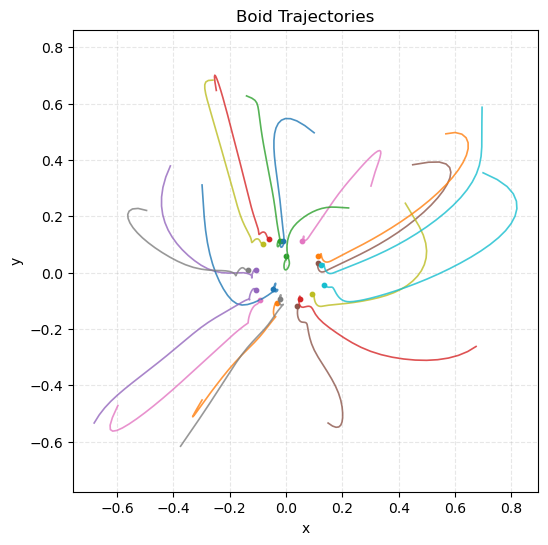

In [ ]:
N = 20
epsilon = 0.1
R = 0.3
d = 0.1
h = 0.3

# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
o20_sol_s = solve_ivp(f_static, tspan, x20.flatten(), t_eval=t_eval)

plot_boid_trajectories(o20_sol_s,N)

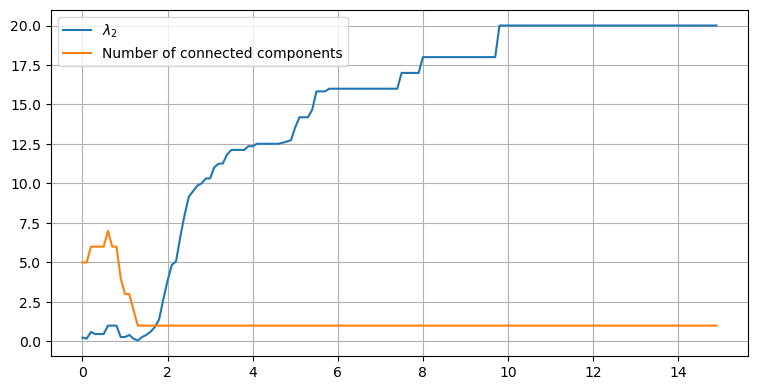

In [ ]:
l2,ca = get_lambda_2(o20_sol_s)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

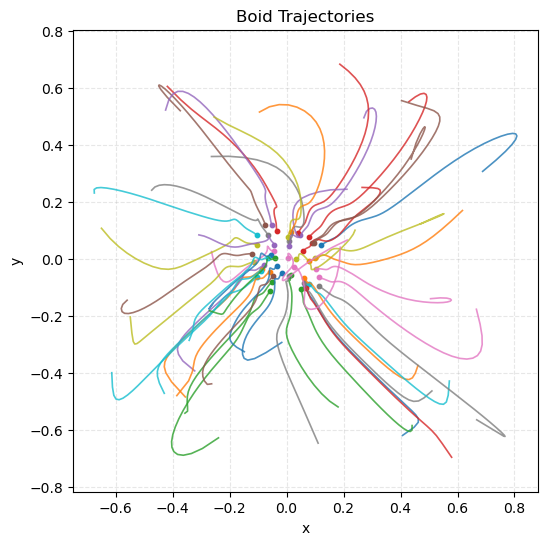

In [109]:
N = 50
o50_sol_s = solve_ivp(f_static, tspan, x50.flatten(), t_eval=t_eval)

plot_boid_trajectories(o50_sol_s,N)

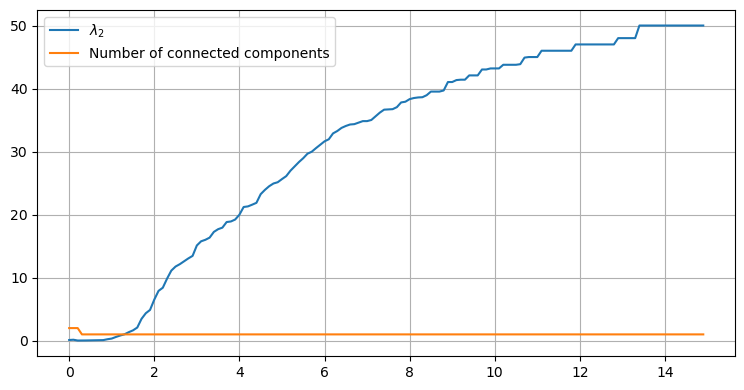

In [110]:
l2,ca = get_lambda_2(o50_sol_s)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

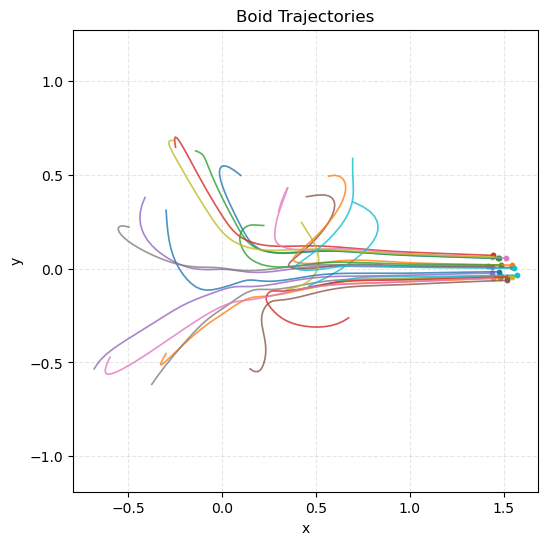

In [112]:
N = 20
vgamma = np.array([[0.1,0]])
# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
o20_sol_d = solve_ivp(f_dynamic, tspan, x20.flatten(), t_eval=t_eval)

plot_boid_trajectories(o20_sol_d,N)

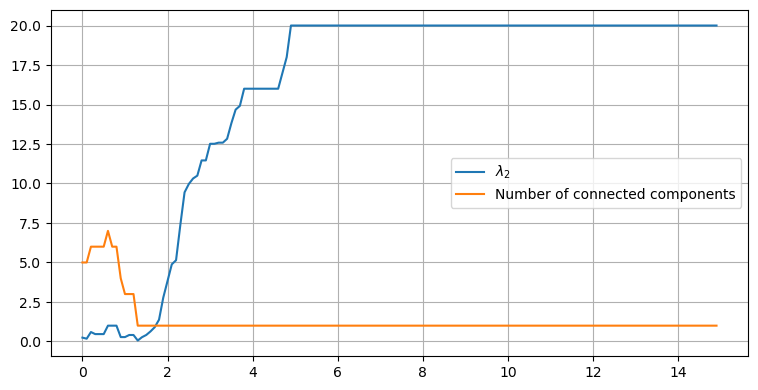

In [113]:
l2,ca = get_lambda_2(o20_sol_d)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

Text(0.5, 1.0, 'average velocity error')

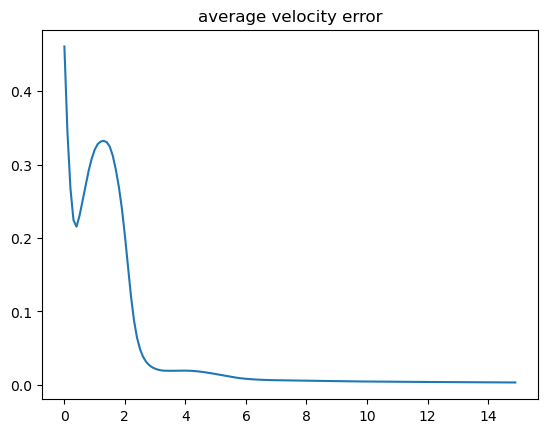

In [118]:
N=20
plt.plot(t_eval,get_avg_velocity_error(o20_sol_d))
plt.title("average velocity error")

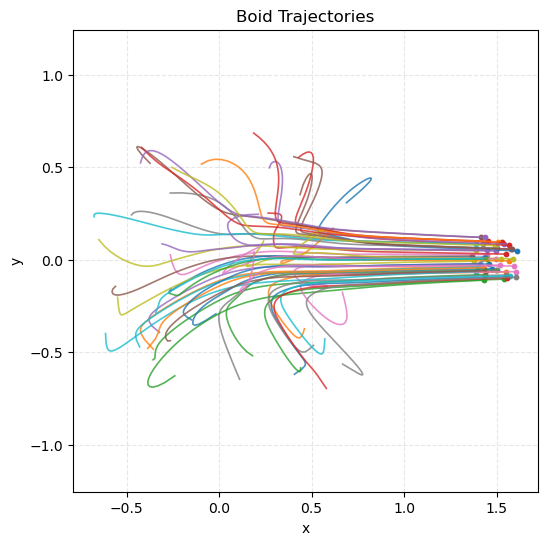

In [114]:
N = 50
vgamma = np.array([[0.1,0]])
# integrate
tspan = (0, 15)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
o50_sol_d = solve_ivp(f_dynamic, tspan, x50.flatten(), t_eval=t_eval)

plot_boid_trajectories(o50_sol_d,N)

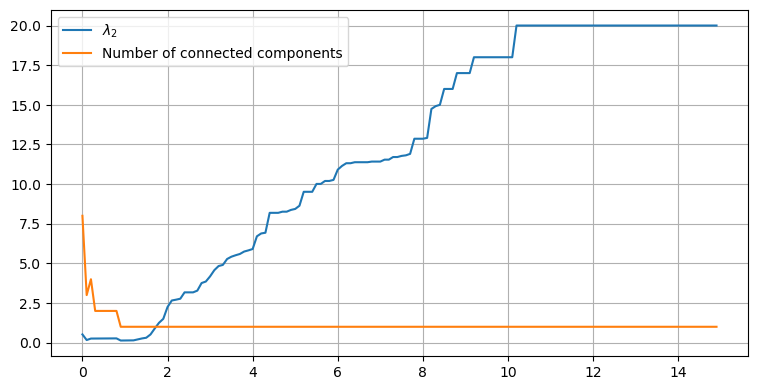

In [119]:
l2,ca = get_lambda_2(o50_sol_d)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

Text(0.5, 1.0, 'average velocity error')

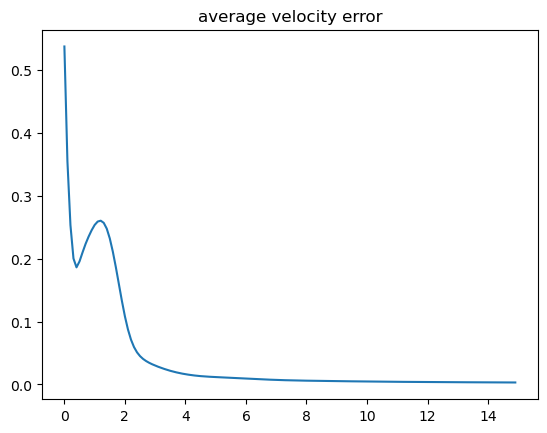

In [121]:
N=50
plt.plot(t_eval,get_avg_velocity_error(o50_sol_d))
plt.title("average velocity error")